# Proyek Analisis Data: [Bike Sharing]
- **Nama:** Rezha Dwi Cahya Ardinata
- **Email:** cdcc006d6y1939@student.devacademy.id
- **ID Dicoding:** rezhadwii


## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana perbandingan tren total penyewaan sepeda setiap bulan antara tahun 2011 dan 2012, serta pada bulan apa terjadi penyewaan tertinggi dan terendah?

- **Pertanyaan 2:** Bagaimana perbedaan rata-rata penyewaan sepeda pada berbagai musim dan kondisi cuaca antara tahun 2011 dan 2012?

- **Pertanyaan 3:** Bagaimana perbedaan pola rata-rata penyewaan sepeda per jam antara working day dan non-working day selama tahun 2011–2012?

### Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
hour_bike = pd.read_csv("/content/hour.csv")
hour_bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight**

Lima baris pertama menunjukkan bahwa dataset ini berisi catatan penyewaan sepeda per jam. Informasi waktu tersedia pada kolom seperti `dteday`, `yr`, `mnth`, `hr`, dan `weekday`. Kondisi eksternal seperti musim dan cuaca terdapat pada kolom `season`, `weathersit`, `temp`, `hum`, dan `windspeed`. Kolom `casual`, `registered`, dan `cnt` menunjukkan jumlah penyewaan sepeda.

### Assessing Data

**Steps to Take:**
- Memeriksa struktur data dan tipe data pada setiap kolom.
- Memeriksa missing value pada dataset.
- Memeriksa duplicate data.
- Melihat ringkasan statistik.

In [ ]:
hour_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
hour_bike.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
hour_bike.duplicated().sum()

np.int64(0)

In [ ]:
hour_bike.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**

- Dataset hour_bike terdiri dari 17.379 catatan penyewaan sepeda per jam dan 17 kolom.
- Tidak ditemukan missing value pada seluruh kolom, sehingga tidak diperlukan proses imputasi atau penghapusan nilai kosong.
- Tidak ditemukan data duplikat, sehingga dataset dapat digunakan tanpa proses penghapusan duplikasi.
- Kolom dteday masih bertipe object, perlu diubah menjadi tipe datetime agar dapat digunakan untuk analisis berbasis waktu.
- Nilai pada kolom cnt berada pada rentang 1 hingga 977 penyewaan per jam, menunjukkan adanya variasi jumlah penyewaan yang cukup besar antarwaktu.

### Cleaning Data

In [ ]:
# Mengubah kolom dteday menjadi tipe datetime
hour_bike["dteday"] = pd.to_datetime(hour_bike["dteday"])

In [ ]:
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

hour_bike["season"] = hour_bike["season"].map(season_map)

In [ ]:
weather_map = {
    1: "Clear",
    2: "Mist/Cloudy",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}

hour_bike["weathersit"] = hour_bike["weathersit"].map(weather_map)

In [ ]:
year_map = {
    0: 2011,
    1: 2012
}

hour_bike["yr"] = hour_bike["yr"].map(year_map)

In [ ]:
month_map = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

hour_bike["mnth"] = hour_bike["mnth"].map(month_map)

In [ ]:
workingday_map = {
    0: "Non-Working Day",
    1: "Working Day"
}

hour_bike["workingday"] = hour_bike["workingday"].map(workingday_map)

In [ ]:
weekday_map = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

hour_bike["weekday"] = hour_bike["weekday"].map(weekday_map)

In [ ]:
hour_bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,0,Saturday,Non-Working Day,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,0,Saturday,Non-Working Day,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,0,Saturday,Non-Working Day,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,0,Saturday,Non-Working Day,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,0,Saturday,Non-Working Day,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

- Pada tahap cleaning, kolom dteday sudah diubah ke tipe datetime. Hal ini dilakukan karena kolom tersebut berisi tanggal, sehingga lebih mudah digunakan untuk analisis yang berhubungan dengan waktu.

- Beberapa kolom yang awalnya masih berupa kode angka juga sudah diubah menjadi keterangan teks. Misalnya, kolom season diubah menjadi nama musim, mnth menjadi nama bulan, weekday menjadi nama hari, dan weathersit menjadi keterangan kondisi cuaca.

- Pada tahap sebelumnya tidak ditemukan missing value maupun data duplikat, sehingga tidak ada proses penghapusan atau pengisian nilai kosong yang dilakukan.

- Setelah proses cleaning, dataset menjadi lebih siap digunakan untuk tahap EDA, terutama untuk menganalisis pola penyewaan sepeda berdasarkan waktu, musim, hari, hari kerja, dan kondisi cuaca.

## Exploratory Data Analysis (EDA)

In [ ]:
hour_bike.describe()

,instant,dteday,yr,hr,holiday,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2011.502561,11.546752,0.028770,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,2011.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2011.000000,6.000000,0.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,2012.000000,12.000000,0.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,2012.000000,18.000000,0.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,2012.000000,23.000000,1.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,0.500008,6.914405,0.167165,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [ ]:
monthly_yearly_rentals = hour_bike.groupby(["yr", "mnth"], as_index=False).agg({
    "cnt": "sum"
})

monthly_yearly_rentals

,yr,mnth,cnt
0,2011,April,94870
1,2011,August,136691
2,2011,December,87323
3,2011,February,48215
4,2011,January,38189
5,2011,July,141341
6,2011,June,143512
7,2011,March,64045
8,2011,May,135821
9,2011,November,102167


In [ ]:
# Menampilkan bulan dengan total penyewaan sepeda tertinggi
monthly_yearly_rentals.sort_values(by="cnt", ascending=False).head()

,yr,mnth,cnt
23,2012,September,218573
13,2012,August,214503
17,2012,July,203607
18,2012,June,202830
22,2012,October,198841


In [ ]:
# Menampilkan bulan dengan total penyewaan sepeda terendah
monthly_yearly_rentals.sort_values(by="cnt", ascending=True).head()

,yr,mnth,cnt
4,2011,January,38189
3,2011,February,48215
7,2011,March,64045
2,2011,December,87323
0,2011,April,94870


In [ ]:
# Menghitung rata-rata penyewaan sepeda berdasarkan musim
season_year_rentals = hour_bike.groupby(["yr", "season"], as_index=False).agg({
    "cnt": "mean"
})

season_year_rentals.sort_values(by="cnt", ascending=False)

,yr,season,cnt
4,2012,Fall,284.343528
6,2012,Summer,258.963282
7,2012,Winter,245.698761
0,2011,Fall,187.343750
2,2011,Summer,157.655924
3,2011,Winter,152.828960
5,2012,Spring,147.814167
1,2011,Spring,72.533849


In [ ]:
# Menghitung rata-rata penyewaan sepeda berdasarkan kondisi cuaca
weather_year_rentals = hour_bike.groupby(["yr", "weathersit"], as_index=False).agg({
    "cnt": "mean"
})

weather_year_rentals.sort_values(by="cnt", ascending=False)

,yr,weathersit,cnt
4,2012,Clear,253.661581
7,2012,Mist/Cloudy,212.997850
0,2011,Clear,155.013818
6,2012,Light Rain/Snow,142.376176
3,2011,Mist/Cloudy,135.490983
5,2012,Heavy Rain/Snow,93.500000
2,2011,Light Rain/Snow,86.421255
1,2011,Heavy Rain/Snow,36.000000


In [ ]:
# Menghitung rata-rata penyewaan sepeda berdasarkan jam dan tipe hari
hourly_workingday = hour_bike.groupby(["hr", "workingday"], as_index=False).agg({
    "cnt": "mean"
})

hourly_workingday

,hr,workingday,cnt
0,0,Non-Working Day,90.800000
1,0,Working Day,36.786290
2,1,Non-Working Day,69.508696
3,1,Working Day,16.552632
4,2,Non-Working Day,53.171053
5,2,Working Day,8.683778
6,3,Non-Working Day,25.775330
7,3,Working Day,4.942553
8,4,Non-Working Day,8.264317
9,4,Working Day,5.429787


In [ ]:
# Menampilkan jam dengan rata-rata penyewaan tertinggi berdasarkan tipe hari
hourly_workingday.sort_values(by="cnt", ascending=False).head()

,hr,workingday,cnt
35,17,Working Day,525.290581
37,18,Working Day,492.226908
17,8,Working Day,477.006048
26,13,Non-Working Day,372.731602
24,12,Non-Working Day,366.259740


**Insight:**

- Setelah data dikelompokkan berdasarkan tahun dan bulan, terlihat bahwa total penyewaan sepeda pada tahun 2012 lebih tinggi dibandingkan tahun 2011. Penyewaan tertinggi terjadi pada September 2012 dengan 218.573 penyewaan, sedangkan penyewaan terendah terjadi pada Januari 2011 dengan 38.189 penyewaan. Dari tabel bulanan, penyewaan pada tahun 2012 juga terlihat mendominasi posisi tertinggi, terutama pada bulan September, Agustus, Juli, Juni, dan Oktober.

- Berdasarkan musim, rata-rata penyewaan sepeda pada tahun 2012 lebih tinggi dibandingkan tahun 2011 di setiap musim. Rata-rata tertinggi terjadi pada musim Fall tahun 2012, yaitu sekitar 284 penyewaan per jam. Sebaliknya, rata-rata terendah terjadi pada musim Spring tahun 2011, yaitu sekitar 72 penyewaan per jam. Hal ini menunjukkan bahwa tahun dan musim sama-sama berkaitan dengan perbedaan tingkat penyewaan sepeda.

- Berdasarkan kondisi cuaca, rata-rata penyewaan tertinggi terjadi saat cuaca Clear pada tahun 2012, yaitu sekitar 254 penyewaan per jam. Rata-rata penyewaan menurun pada kondisi Mist/Cloudy dan Light Rain/Snow. Rata-rata terendah terjadi pada kondisi Heavy Rain/Snow tahun 2011, yaitu sekitar 36 penyewaan per jam. Pola ini menunjukkan bahwa cuaca yang lebih mendukung cenderung memiliki rata-rata penyewaan yang lebih tinggi.

- Berdasarkan jam dan tipe hari, pola penyewaan pada Working Day dan Non-Working Day terlihat berbeda. Pada Working Day, rata-rata penyewaan tertinggi terjadi pada jam 17.00, jam 18.00 dan jam 08.00. Pola ini menunjukkan adanya peningkatan pada waktu yang berkaitan dengan aktivitas berangkat dan pulang kerja atau sekolah. Sementara itu, pada Non-Working Day, rata-rata penyewaan lebih tinggi pada siang hingga sore hari, terutama sekitar jam 12.00–16.00.


## Visualization & Explanatory Analysis

### Pertanyaan 1:Bagaimana perbandingan tren total penyewaan sepeda setiap bulan antara tahun 2011 dan 2012, serta pada bulan apa terjadi penyewaan tertinggi dan terendah?


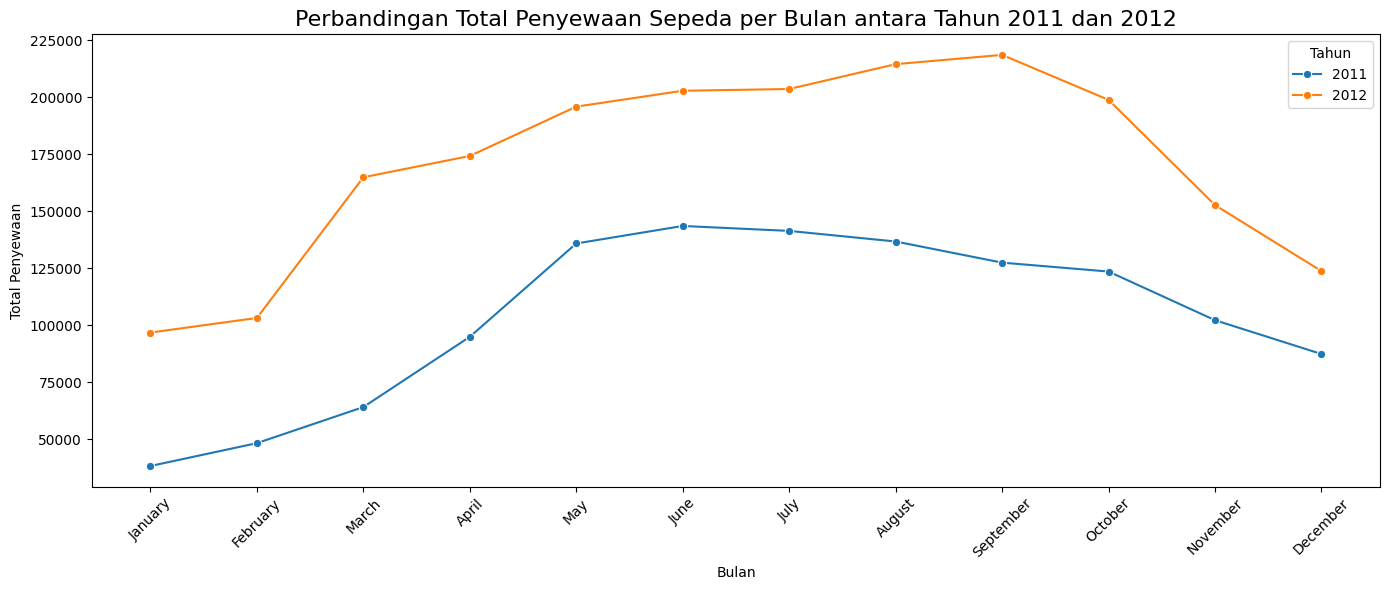

In [ ]:

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_yearly_rentals = hour_bike.groupby(["yr", "mnth"], as_index=False).agg({
    "cnt": "sum"
})

monthly_yearly_rentals["mnth"] = pd.Categorical(
    monthly_yearly_rentals["mnth"],
    categories=month_order,
    ordered=True
)

monthly_yearly_rentals = monthly_yearly_rentals.sort_values(["yr", "mnth"])

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_yearly_rentals,
    x="mnth",
    y="cnt",
    hue="yr",
    marker="o",
    palette=["tab:blue", "tab:orange"]
)

plt.title("Perbandingan Total Penyewaan Sepeda per Bulan antara Tahun 2011 dan 2012", fontsize=16)
plt.xlabel("Bulan")
plt.ylabel("Total Penyewaan")
plt.xticks(rotation=45)
plt.legend(title="Tahun")
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana perbedaan rata-rata penyewaan sepeda pada berbagai musim dan kondisi cuaca antara tahun 2011 dan 2012?



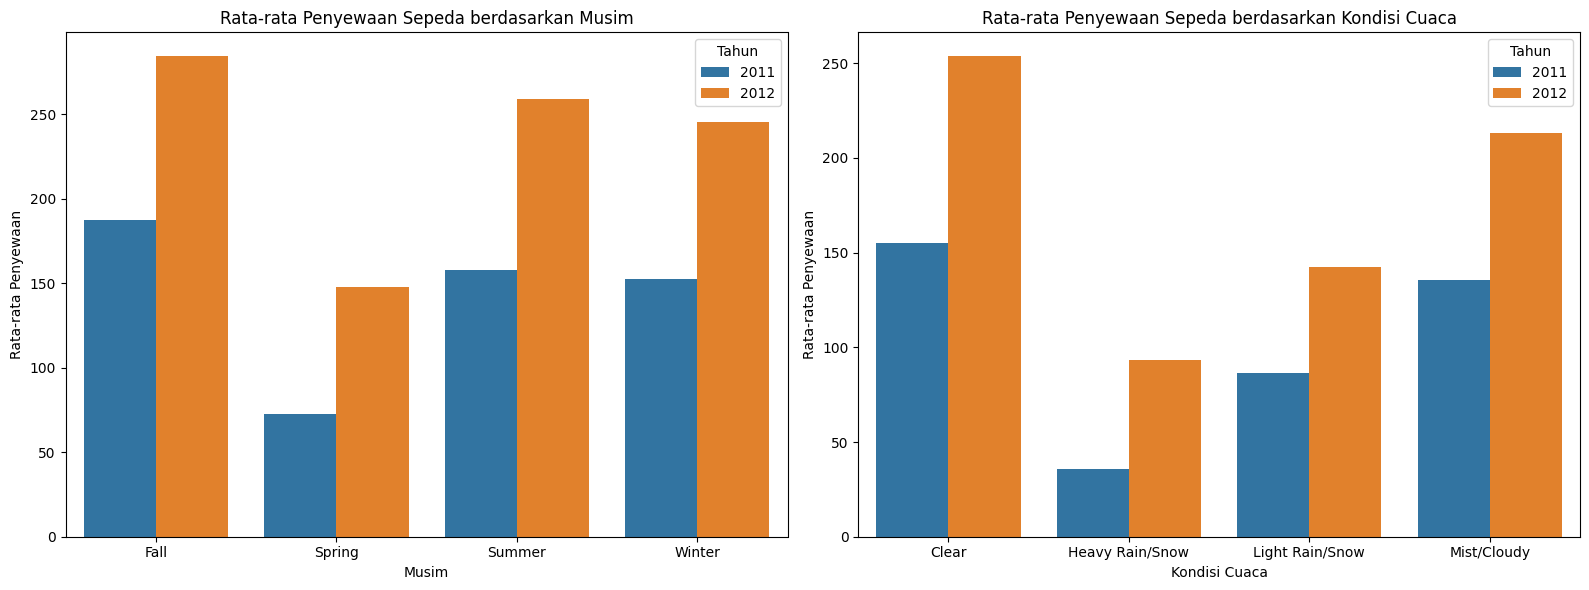

In [ ]:
season_year_rentals = hour_bike.groupby(["yr", "season"], as_index=False).agg({
    "cnt": "mean"
})

weather_year_rentals = hour_bike.groupby(["yr", "weathersit"], as_index=False).agg({
    "cnt": "mean"
})

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.barplot(
    data=season_year_rentals,
    x="season",
    y="cnt",
    hue="yr",
    palette=["tab:blue", "tab:orange"],
    ax=ax[0]
)

ax[0].set_title("Rata-rata Penyewaan Sepeda berdasarkan Musim")
ax[0].set_xlabel("Musim")
ax[0].set_ylabel("Rata-rata Penyewaan")
ax[0].legend(title="Tahun")

sns.barplot(
    data=weather_year_rentals,
    x="weathersit",
    y="cnt",
    hue="yr",
    palette=["tab:blue", "tab:orange"],
    ax=ax[1]
)

ax[1].set_title("Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca")
ax[1].set_xlabel("Kondisi Cuaca")
ax[1].set_ylabel("Rata-rata Penyewaan")
ax[1].legend(title="Tahun")

plt.tight_layout()
plt.show()

### Pertanyaan 3: Bagaimana perbedaan pola rata-rata penyewaan sepeda per jam antara working day dan non-working day selama tahun 2011–2012?


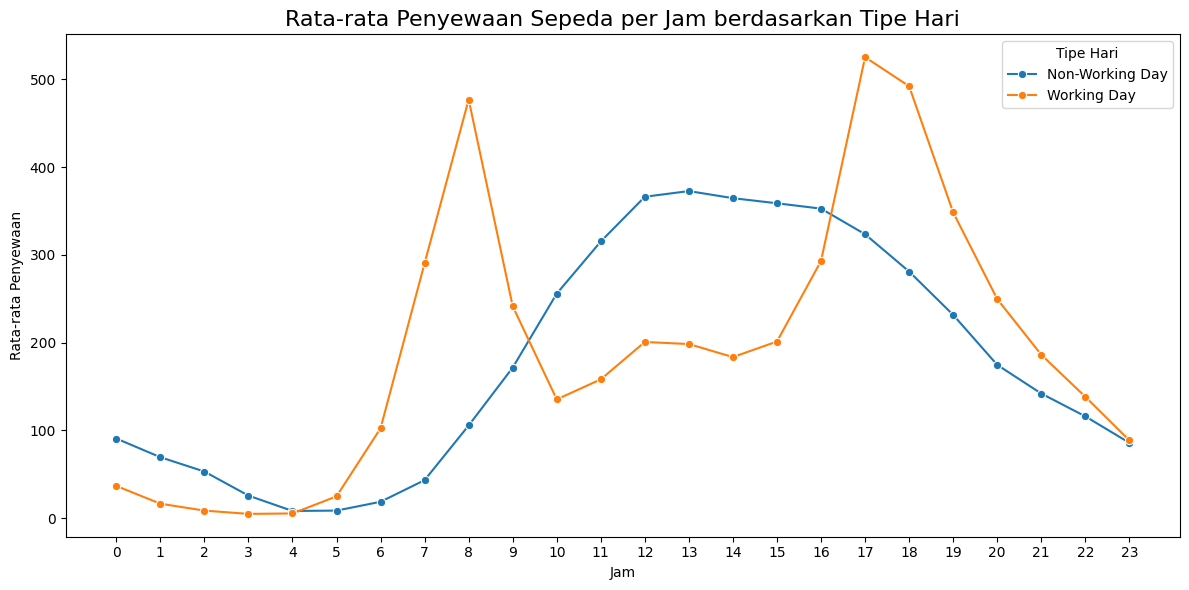

In [ ]:
hourly_workingday = hour_bike.groupby(["hr", "workingday"], as_index=False).agg({
    "cnt": "mean"
})

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=hourly_workingday,
    x="hr",
    y="cnt",
    hue="workingday",
    marker="o"
)

plt.title("Rata-rata Penyewaan Sepeda per Jam berdasarkan Tipe Hari", fontsize=16)
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0, 24))
plt.legend(title="Tipe Hari")
plt.tight_layout()
plt.show()


**Insight:**

- Pada pertanyaan pertama, grafik menunjukkan bahwa total penyewaan sepeda pada tahun 2012 lebih tinggi dibandingkan tahun 2011 pada setiap bulan. Pada kedua tahun, penyewaan cenderung meningkat dari awal tahun menuju pertengahan hingga akhir tahun, lalu menurun kembali menjelang akhir tahun. Total penyewaan tertinggi terjadi pada September 2012, sedangkan total penyewaan terendah terjadi pada Januari 2011.

- Pada pertanyaan kedua, rata-rata penyewaan sepeda pada tahun 2012 terlihat lebih tinggi dibandingkan tahun 2011 pada setiap musim dan kondisi cuaca. Berdasarkan musim, rata-rata penyewaan tertinggi terjadi pada musim Fall, sedangkan yang terendah terjadi pada musim Spring. Berdasarkan kondisi cuaca, rata-rata penyewaan tertinggi terjadi saat cuaca Clear, sedangkan yang terendah terjadi saat Heavy Rain/Snow. Hal ini menunjukkan bahwa musim dan kondisi cuaca berhubungan dengan tingkat penyewaan sepeda.

- Pada pertanyaan ketiga, grafik menunjukkan adanya perbedaan pola penyewaan sepeda antara Working Day dan Non-Working Day. Pada Working Day, penyewaan meningkat tajam pada pagi hari sekitar jam 08.00 dan sore hari sekitar jam 17.00–18.00, hal ini berkaitan dengan aktivitas rutin seperti berangkat dan pulang kerja atau sekolah. Pada Non-Working Day, penyewaan lebih banyak terjadi pada waktu siang hingga sore hari, sehingga polanya lebih menyebar dan tidak terlalu terpusat pada jam sibuk.

## Analisis Lanjutan

Pada bagian ini dilakukan pengelompokan tingkat demand penyewaan sepeda berdasarkan rata-rata penyewaan per jam dan tipe hari. Pengelompokan dilakukan secara sederhana menggunakan batas nilai tertentu untuk membagi demand menjadi low, medium, dan high demand.

In [ ]:
demand_by_hour_day = hour_bike.groupby(["workingday", "hr"], as_index=False).agg({
    "cnt": "mean"
})

def demand_level(avg_rentals):
    if avg_rentals < 150:
        return "Low Demand"
    elif avg_rentals < 300:
        return "Medium Demand"
    else:
        return "High Demand"

demand_by_hour_day["demand_level"] = demand_by_hour_day["cnt"].apply(demand_level)

demand_by_hour_day

,workingday,hr,cnt,demand_level
0,Non-Working Day,0,90.800000,Low Demand
1,Non-Working Day,1,69.508696,Low Demand
2,Non-Working Day,2,53.171053,Low Demand
3,Non-Working Day,3,25.775330,Low Demand
4,Non-Working Day,4,8.264317,Low Demand
5,Non-Working Day,5,8.689189,Low Demand
6,Non-Working Day,6,18.742358,Low Demand
7,Non-Working Day,7,43.406926,Low Demand
8,Non-Working Day,8,105.653680,Low Demand
9,Non-Working Day,9,171.623377,Medium Demand


In [ ]:
demand_summary = demand_by_hour_day.groupby(["workingday", "demand_level"]).agg({
    "hr": list,
    "cnt": "mean"
}).reset_index()

demand_summary

,workingday,demand_level,hr,cnt
0,Non-Working Day,High Demand,"[11, 12, 13, 14, 15, 16, 17]",350.577613
1,Non-Working Day,Low Demand,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 21, 22, 23]",64.005310
2,Non-Working Day,Medium Demand,"[9, 10, 18, 19, 20]",223.000407
3,Working Day,High Demand,"[8, 17, 18, 19]",460.731286
4,Working Day,Low Demand,"[0, 1, 2, 3, 4, 5, 6, 10, 22, 23]",56.227350
5,Working Day,Medium Demand,"[7, 9, 11, 12, 13, 14, 15, 16, 20, 21]",220.364341


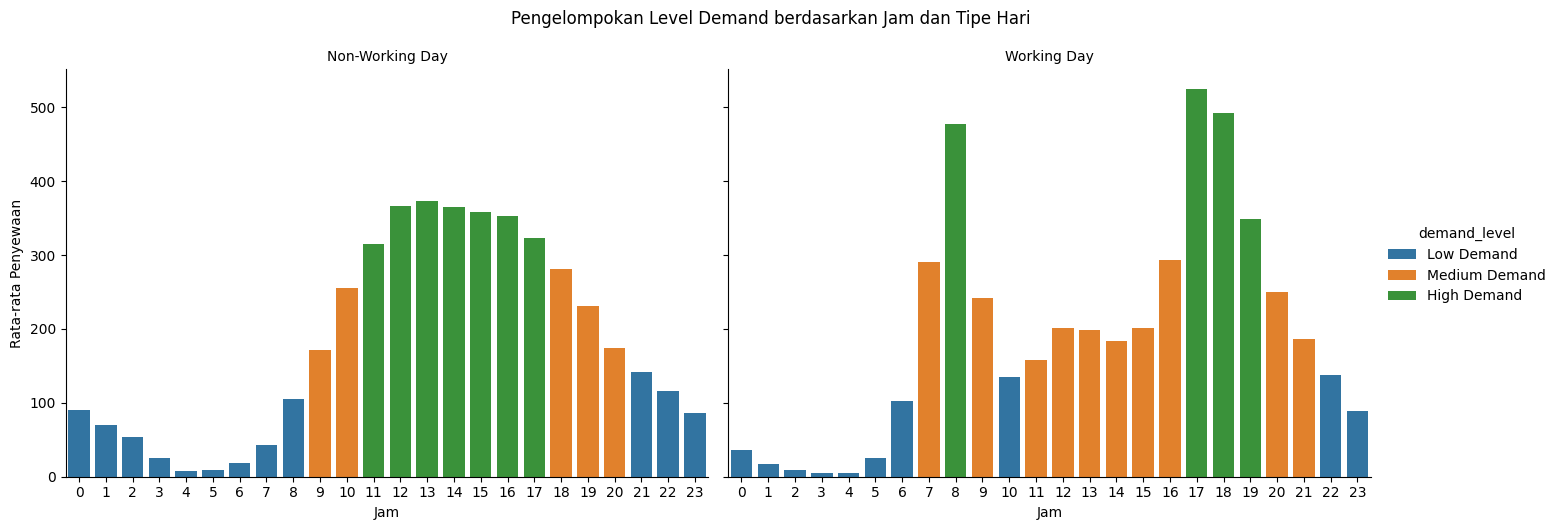

In [ ]:
g = sns.catplot(
    data=demand_by_hour_day,
    x="hr",
    y="cnt",
    hue="demand_level",
    col="workingday",
    kind="bar",
    height=5,
    aspect=1.4
)

g.set_axis_labels("Jam", "Rata-rata Penyewaan")
g.set_titles("{col_name}")
g.fig.suptitle("Pengelompokan Level Demand berdasarkan Jam dan Tipe Hari", y=1.05)
plt.show()

**Insight:**

- Pada non-working day, kategori high demand terjadi pada jam 11.00–17.00. Hal ini menunjukkan bahwa penyewaan sepeda pada non-hari kerja atau hari libur cenderung tinggi pada siang hingga sore hari, yang berkaitan dengan aktivitas santai, rekreasi, atau kegiatan luar ruangan.

- Pada working day, kategori high demand terjadi pada jam 08.00 dan 17.00–19.00. Pola ini menunjukkan adanya peningkatan permintaan seperti berangkat atau pulang aktivitas seperti sekolah maupun kerja.

- Kategori low demand pada non-working day banyak terjadi pada waktu malam hari hingga pagi, serta malam hari. Sedangkan pada working day, low demand banyak terjadi pada dini hari dan malam hari. Waktu pada saat low demand ini dapat dimanfaatkan untuk pengecekan kondisi sepeda atau penataan ulang unit sepeda.

- Pengelompokan low, medium, dan high demand membantu menyederhanakan pola penyewaan sepeda berdasarkan jam dan tipe hari, sehingga pengelola dapat menentukan prioritas penyediaan sepeda dengan lebih mudah.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**  
  Berdasarkan hasil analisis, total penyewaan sepeda pada tahun 2012 lebih tinggi dibandingkan tahun 2011 pada setiap bulan. Pada kedua tahun, penyewaan cenderung meningkat dari awal tahun menuju pertengahan hingga akhir tahun, kemudian menurun kembali menjelang akhir tahun. Total penyewaan tertinggi terjadi pada September 2012, sedangkan total penyewaan terendah terjadi pada Januari 2011. Hal ini menunjukkan adanya peningkatan penggunaan layanan bike sharing dari tahun 2011 ke tahun 2012.

- **Conclusion pertanyaan 2:**  
  Berdasarkan hasil analisis, rata-rata penyewaan sepeda pada tahun 2012 cenderung lebih tinggi dibandingkan tahun 2011 pada berbagai musim dan kondisi cuaca. Dari sisi musim, rata-rata penyewaan tertinggi terjadi pada musim Fall, sedangkan yang terendah terjadi pada musim Spring. Dari sisi kondisi cuaca, rata-rata penyewaan tertinggi terjadi saat cuaca Clear, sedangkan yang terendah terjadi saat Heavy Rain/Snow. Hal ini menunjukkan bahwa musim dan kondisi cuaca berkaitan dengan tingkat penyewaan sepeda.

- **Conclusion pertanyaan 3:**  
  Berdasarkan hasil visualisasi, pola rata-rata penyewaan sepeda per jam pada working day dan non-working day memiliki perbedaan. Pada working day, penyewaan meningkat pada pagi hari sekitar jam 08.00 dan sore hari sekitar jam 17.00–18.00. Pola ini berkaitan dengan aktivitas rutin seperti berangkat dan pulang kerja atau sekolah. Sementara itu, pada non-working day, penyewaan lebih banyak terjadi pada siang hingga sore hari. Dengan adanya pemisahan tipe hari, pola penyewaan menjadi lebih jelas dibandingkan jika seluruh hari digabung dalam satu rata-rata.

- **Conclusion analisis lanjutan:**  
  Berdasarkan pengelompokan level demand, periode high demand pada working day terjadi pada jam 08.00 dan 17.00–19.00, sedangkan pada non-working day terjadi pada jam 11.00–17.00. Periode low demand banyak terjadi pada dini hari dan malam hari. Hasil ini dapat membantu pengelola menentukan waktu prioritas penyediaan sepeda serta waktu yang lebih tepat untuk pengecekan atau penataan ulang unit sepeda yang disewakan.

**Rekomendasi Action Item:**

- Pengelola layanan dapat memperhatikan periode dengan total penyewaan tinggi, terutama pada pertengahan hingga akhir tahun. Karena total penyewaan pada tahun 2012 lebih tinggi dibandingkan tahun 2011, periode dengan tren peningkatan dapat menjadi acuan untuk menyiapkan jumlah sepeda dan kapasitas layanan yang lebih baik.

- Pada musim Fall, jumlah sepeda yang tersedia sebaiknya dipersiapkan lebih banyak karena musim tersebut memiliki rata-rata penyewaan tertinggi. Sebaliknya, pada musim Spring yang memiliki rata-rata penyewaan lebih rendah, pengelola dapat mempertimbangkan strategi promosi atau program khusus untuk meningkatkan minat pengguna.

- Saat cuaca Clear, ketersediaan sepeda perlu lebih diperhatikan karena kondisi cuaca tersebut memiliki rata-rata penyewaan tertinggi. Pada kondisi cuaca yang kurang mendukung, seperti Mist/Cloudy, Light Rain/Snow, dan Heavy Rain/Snow, pengelola dapat menyesuaikan ekspektasi permintaan serta mempertimbangkan promosi ringan agar penggunaan layanan tetap terjaga.

- Pada working day, sepeda sebaiknya lebih banyak tersedia pada jam sibuk, terutama sekitar jam 08.00 serta 17.00–19.00, karena berkaitan dengan faktor seperti aktivitas berangkat dan pulang kerja atau sekolah.

- Pada non-working day, ketersediaan sepeda dapat lebih difokuskan pada siang hingga sore hari, karena permintaan tinggi lebih banyak terjadi pada jam jam 11.00–17.00.

- Periode low demand, terutama pada dini hari dan malam hari, dapat dimanfaatkan untuk pengecekan kondisi sepeda, perawatan ringan, dan penataan ulang unit sepeda agar tidak mengganggu pengguna pada jam krusial atau ramai pengguna.